In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
print(sys.path)

['/Users/jtucker/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python312.zip', '/Users/jtucker/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12', '/Users/jtucker/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/lib-dynload', '', '/Users/jtucker/src/tastetester/.venv/lib/python3.12/site-packages', '/Users/jtucker/src/tastetester']


,track_name,artist_name,album_name,total_plays,total_playtime_ms,years_listened,most_recent_year,peak_year,danceability,energy,...,acousticness,valence,instrumentalness,liveness,speechiness,loudness,genres,total_tracks,release_date_year,top_genre
spotify_track_uri,,,,,,,,,,,,,,,,,,,,,
spotify:track:00RYw42tKwXecTaVay3BKl,Howling At The Moon,Phantogram,Voices,1,238186,1,2017,2017.0,0.597,0.965,...,0.016600,0.151,0.000116,0.1950,0.0446,-1.420,"[glitch pop, indie pop, indietronica]",9.537736,2015,glitch pop
spotify:track:01PW4iTCvh9cUHPF0eV7H3,Time Consumer,Coheed and Cambria,The Second Stage Turbine Blade (Re-Issue),2,683386,1,2018,2018.0,0.294,0.959,...,0.000437,0.481,0.000053,0.0858,0.0627,-2.794,"[alternative rock, progressive metal, progress...",9.537736,2015,alternative rock
spotify:track:01iiEi9h8CQGUN2K1xBbTj,List Of People (To Try And Forget About),Tame Impala,Currents B-Sides & Remixes,1,279986,1,2019,2019.0,0.409,0.792,...,0.088100,0.195,0.000576,0.1030,0.0415,-5.680,"[neo-psychedelia, psychedelic pop, psychedelic...",9.537736,2015,neo-psychedelia
spotify:track:029O4HWI1pVXLfFdfQd1Jb,Superheroes / Human After All / Rock'n Roll,Daft Punk,Alive 2007,1,341106,1,2017,2017.0,0.487,0.723,...,0.000045,0.391,0.383000,0.8190,0.1430,-11.148,"[electronic, french house, house]",9.537736,2015,electronic
spotify:track:02CFIyKrZuhXbk4NYjmYc6,Procellous,Caspian,Waking Season,2,747678,1,2017,2017.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"[instrumental, instrumental rock, post-rock]",9.537736,2015,instrumental


array([[<Axes: title={'center': 'acid techno'}>,
        <Axes: title={'center': 'alternative rock'}>,
        <Axes: title={'center': 'ambient'}>,
        <Axes: title={'center': 'art punk'}>],
       [<Axes: title={'center': 'blues'}>,
        <Axes: title={'center': 'blues rock'}>,
        <Axes: title={'center': 'chillout'}>,
        <Axes: title={'center': 'classical'}>],
       [<Axes: title={'center': 'electronic'}>,
        <Axes: title={'center': 'experimental'}>,
        <Axes: title={'center': 'glitch pop'}>,
        <Axes: title={'center': 'indie rock'}>],
       [<Axes: title={'center': 'instrumental'}>,
        <Axes: title={'center': 'math'}>,
        <Axes: title={'center': 'math rock'}>,
        <Axes: title={'center': 'neo-psychedelia'}>],
       [<Axes: title={'center': 'pop'}>,
        <Axes: title={'center': 'post-rock'}>, <Axes: >, <Axes: >]],
      dtype=object)

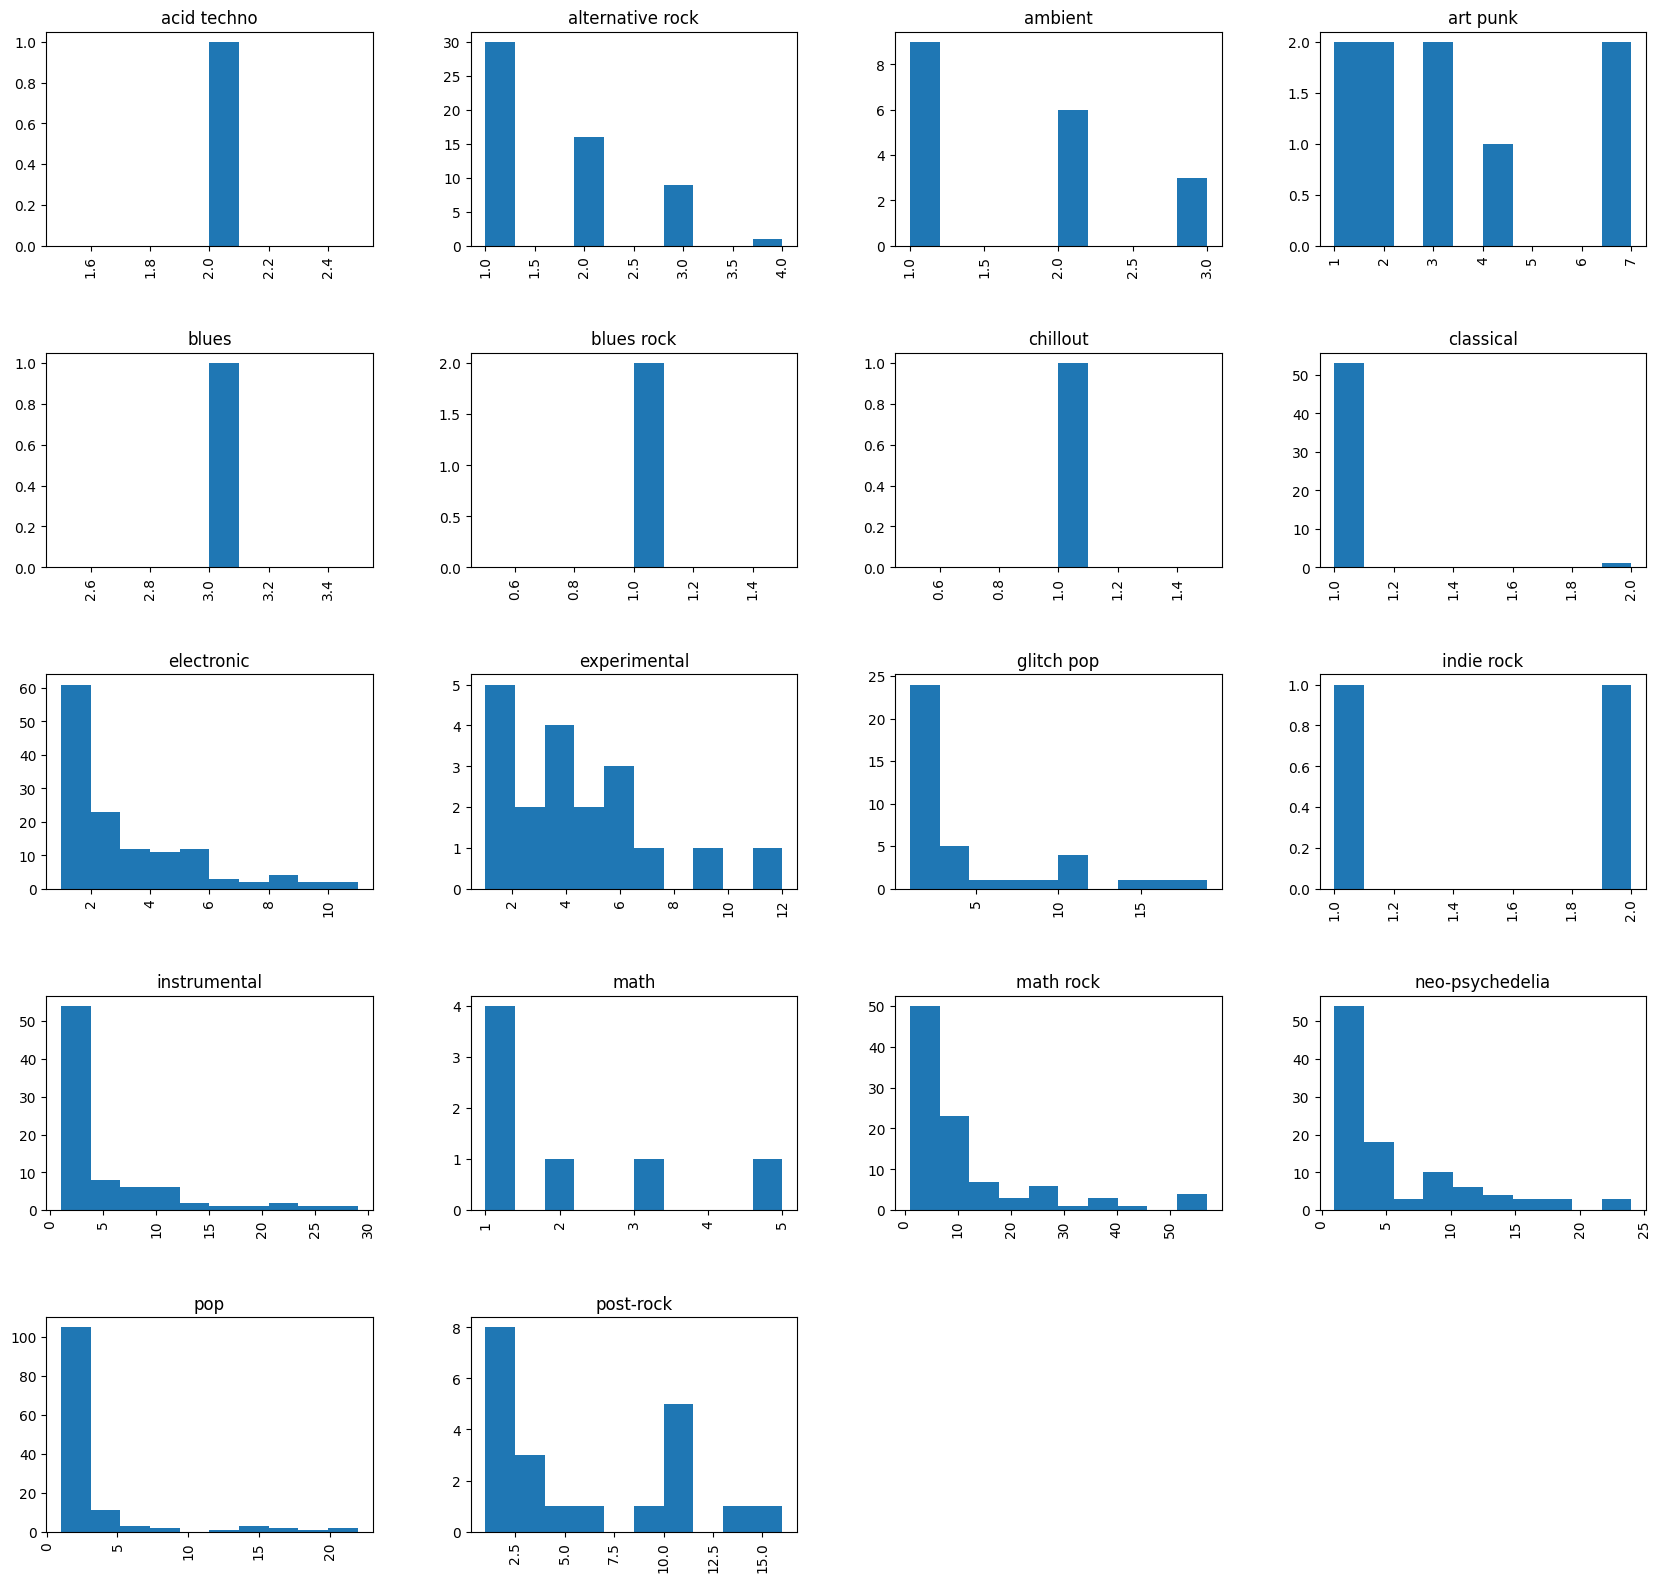

In [3]:
import json

import pandas as pd
from etl.common.vectorstore import ListeningVectorStore

store = ListeningVectorStore()
tracks = store.execute("SELECT * FROM track_details").fetchall()
df_tracks = pd.DataFrame.from_records(tracks, columns=tracks[0].keys(), index="spotify_track_uri")
df_tracks['genres'] = df_tracks['genres'].apply(lambda x: json.loads(x) or [])
df_tracks['top_genre'] = df_tracks['genres'].apply(lambda x: x[0] if len(x) > 0 else None)
display(df_tracks.head())

df_tracks['total_plays'].hist(by=df_tracks["top_genre"], figsize=(20, 20))

In [4]:
from app.recommender import recommend
import logging

logging.getLogger().setLevel(logging.DEBUG)

track = "09eSdS5RTgyodJt3krr5AC"
recommendations = recommend(track)
print(recommendations)

DEBUG:root:Loading vector store
DEBUG:root:Fetching track details for 09eSdS5RTgyodJt3krr5AC
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): api.reccobeats.com:443
DEBUG:urllib3.connectionpool:https://api.reccobeats.com:443 "GET /v1/track?ids=09eSdS5RTgyodJt3krr5AC HTTP/1.1" 200 None
DEBUG:root:Got details {'id': '27736c03-57ac-40ba-b6ba-b2971f2cee25', 'trackTitle': 'Answer', 'artists': [{'id': 'a5223065-e579-44e9-8fb5-e11508acfa49', 'name': 'Phantogram', 'href': 'https://open.spotify.com/artist/1l9d7B8W0IHy3LqWsxP2SH'}], 'durationMs': 231600, 'isrc': 'USUM71605177', 'ean': None, 'upc': None, 'href': 'https://open.spotify.com/track/09eSdS5RTgyodJt3krr5AC', 'availableCountries': 'AR,AU,AT,BE,BO,BR,BG,CA,CL,CO,CR,CY,CZ,DK,DO,DE,EC,EE,SV,FI,FR,GR,GT,HN,HK,HU,IS,IE,IT,LV,LT,LU,MY,MT,MX,NL,NZ,NI,NO,PA,PY,PE,PH,PL,PT,SG,SK,ES,SE,CH,TW,TR,UY,US,GB,AD,LI,MC,ID,JP,TH,VN,RO,IL,ZA,SA,AE,BH,QA,OM,KW,EG,MA,DZ,TN,LB,JO,PS,IN,BY,KZ,MD,UA,AL,BA,HR,ME,MK,RS,SI,KR,BD,PK,LK,GH,KE,NG,TZ,UG

{'details': {'id': '27736c03-57ac-40ba-b6ba-b2971f2cee25', 'trackTitle': 'Answer', 'artists': [{'id': 'a5223065-e579-44e9-8fb5-e11508acfa49', 'name': 'Phantogram', 'href': 'https://open.spotify.com/artist/1l9d7B8W0IHy3LqWsxP2SH'}], 'durationMs': 231600, 'isrc': 'USUM71605177', 'ean': None, 'upc': None, 'href': 'https://open.spotify.com/track/09eSdS5RTgyodJt3krr5AC', 'availableCountries': 'AR,AU,AT,BE,BO,BR,BG,CA,CL,CO,CR,CY,CZ,DK,DO,DE,EC,EE,SV,FI,FR,GR,GT,HN,HK,HU,IS,IE,IT,LV,LT,LU,MY,MT,MX,NL,NZ,NI,NO,PA,PY,PE,PH,PL,PT,SG,SK,ES,SE,CH,TW,TR,UY,US,GB,AD,LI,MC,ID,JP,TH,VN,RO,IL,ZA,SA,AE,BH,QA,OM,KW,EG,MA,DZ,TN,LB,JO,PS,IN,BY,KZ,MD,UA,AL,BA,HR,ME,MK,RS,SI,KR,BD,PK,LK,GH,KE,NG,TZ,UG,AG,AM,BS,BB,BZ,BT,BW,BF,CV,CW,DM,FJ,GM,GE,GD,GW,GY,HT,JM,KI,LS,LR,MW,MV,ML,MH,FM,NA,NR,NE,PW,PG,WS,SM,ST,SN,SC,SL,SB,KN,LC,VC,SR,TL,TO,TT,TV,VU,AZ,BN,BI,KH,CM,TD,KM,GQ,SZ,GA,GN,KG,LA,MO,MR,MN,NP,RW,TG,UZ,ZW,BJ,MG,MU,MZ,AO,CI,DJ,ZM,CD,CG,IQ,LY,TJ,VE,ET,XK', 'popularity': 44}, 'vector': array([-0.45786408, -1.05

In [5]:
distances = store.execute("SELECT entity_key, vec_distance_cosine(vector, (SELECT vector FROM track_content_vectors LIMIT 1)) AS distance FROM track_content_vectors").fetchall()
df_distances = pd.DataFrame.from_records(distances, columns=distances[0].keys())

df_distances['distance'].describe()

count    570.000000
mean       0.954397
std        0.328858
min        0.000000
25%        0.736115
50%        0.943708
75%        1.164491
max        1.633187
Name: distance, dtype: float64

In [6]:
from sklearn.metrics.pairwise import pairwise_distances

vectors = store.execute("SELECT entity_key, vec_to_json(vector) AS vector FROM track_content_vectors").fetchall()
keys = store.execute("SELECT feature_columns FROM vector_registry").fetchone()

def parse_row(row):
  entity_key = row['entity_key']
  vector = json.loads(row['vector'])

  return [entity_key] + vector

columns = ['entity_key'] + json.loads(keys['feature_columns'])

df_vectors = pd.DataFrame.from_records(map(parse_row, vectors), columns=columns, index='entity_key')
df_vectors = df_vectors.dropna()
display(df_vectors.head())

df_pairwise_distances = pairwise_distances(df_vectors, metric='cosine')
df_pairwise_distances

,danceability,energy,tempo,acousticness,valence,instrumentalness,liveness,speechiness,loudness,genre:acid techno,...,genre:post-punk,genre:post-rock,genre:progressive metal,genre:progressive rock,genre:psychedelic pop,genre:psychedelic rock,genre:rock,genre:soft rock,genre:synth-pop,genre:synthwave
entity_key,,,,,,,,,,,,,,,,,,,,,
spotify:track:00RYw42tKwXecTaVay3BKl,0.781009,1.228840,-0.753353,-0.596404,-0.571355,-1.457164,-0.120545,-0.279055,1.492771,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
spotify:track:01PW4iTCvh9cUHPF0eV7H3,-0.816346,1.205731,1.208186,-0.648202,0.802739,-1.457333,-0.679933,0.038601,1.238875,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
spotify:track:01iiEi9h8CQGUN2K1xBbTj,-0.210090,0.562543,-0.928511,-0.367265,-0.388142,-1.455924,-0.591824,-0.333460,0.705583,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
spotify:track:029O4HWI1pVXLfFdfQd1Jb,0.201111,0.296795,0.588615,-0.649459,0.427986,-0.425418,3.075957,1.447869,-0.304826,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
spotify:track:03uOJUuuTgaFFI1Efal1no,0.907532,0.797480,-0.542471,1.090567,-0.367323,1.000061,1.047408,-0.515980,0.368533,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


array([[0.        , 0.65373698, 0.44726368, ..., 1.03211843, 1.09566586,
        0.85431109],
       [0.65373698, 0.        , 0.67827716, ..., 0.65426742, 0.59051641,
        0.76992197],
       [0.44726368, 0.67827716, 0.        , ..., 1.09848142, 1.16358763,
        1.08428629],
       ...,
       [1.03211843, 0.65426742, 1.09848142, ..., 0.        , 0.25909721,
        0.40267839],
       [1.09566586, 0.59051641, 1.16358763, ..., 0.25909721, 0.        ,
        0.2724269 ],
       [0.85431109, 0.76992197, 1.08428629, ..., 0.40267839, 0.2724269 ,
        0.        ]], shape=(570, 570))

In [31]:
df_all = df_tracks.join(df_vectors, rsuffix="_")

In [ ]:
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np

df_train = df_all.dropna()
l_all = len(df_all)
print(f"Total tracks in dataset: {l_all}")

total_plays = df_train['total_plays']

# z_scores = np.abs(stats.zscore(total_plays))
# z_threshold = 5
# df_train = df_train[z_scores < z_threshold]
# print(f"Total outliers removed: {l_all - len(df_train)}")

print(f"Average number of plays for tracks in dataset: {total_plays.mean()}")
print(f"Median number of plays for tracks in dataset: {total_plays.median()}")

X = df_train[df_vectors.columns].copy()
X = X.drop(columns='genre:pop')
X = pd.DataFrame(sm.add_constant(X))
display(X.head())

y = df_train['total_plays'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.GLM(y_train, X_train, family=sm.families.Poisson())
results = model.fit(scale='x2')

print(results.summary())

from sklearn.metrics import mean_absolute_error, r2_score
preds = results.predict(X_test)
print('MAE:', mean_absolute_error(y_test.values, preds))
print('corrcoef:', np.corrcoef(y_test.values, preds)[0,1])
print('r^2:', r2_score(y_test.values, preds))

model = sm.GLM(y, X, family=sm.families.Poisson())
results = model.fit(scale='x2')


Total tracks in dataset: 790
Average number of plays for tracks in dataset: 4.693548387096774
Median number of plays for tracks in dataset: 2.0


,const,danceability,energy,tempo,acousticness,valence,instrumentalness,liveness,speechiness,loudness,...,genre:post-punk,genre:post-rock,genre:progressive metal,genre:progressive rock,genre:psychedelic pop,genre:psychedelic rock,genre:rock,genre:soft rock,genre:synth-pop,genre:synthwave
spotify_track_uri,,,,,,,,,,,,,,,,,,,,,
spotify:track:00RYw42tKwXecTaVay3BKl,1.0,0.597,0.965,100.029,0.016600,0.151,0.000116,0.1950,0.0446,-1.420,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
spotify:track:01PW4iTCvh9cUHPF0eV7H3,1.0,0.294,0.959,155.541,0.000437,0.481,0.000053,0.0858,0.0627,-2.794,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
spotify:track:01iiEi9h8CQGUN2K1xBbTj,1.0,0.409,0.792,95.072,0.088100,0.195,0.000576,0.1030,0.0415,-5.680,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
spotify:track:029O4HWI1pVXLfFdfQd1Jb,1.0,0.487,0.723,138.007,0.000045,0.391,0.383000,0.8190,0.1430,-11.148,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
spotify:track:03uOJUuuTgaFFI1Efal1no,1.0,0.621,0.853,105.997,0.543000,0.200,0.912000,0.4230,0.0311,-7.504,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_plays   No. Observations:                  446
Model:                            GLM   Df Residuals:                      419
Model Family:                 Poisson   Df Model:                           26
Link Function:                    Log   Scale:                          4.2267
Method:                          IRLS   Log-Likelihood:                -333.46
Date:                Thu, 04 Jun 2026   Deviance:                       1555.9
Time:                        11:09:03   Pearson chi2:                 1.76e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.5361
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [68]:
import xgboost as xgb
import optuna

def objective(trial):
  pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'validation_0-poisson-nloglik')
  params = {
    "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
    "max_depth": trial.suggest_int("max_depth", 6, 12),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
    "tree_method": trial.suggest_categorical("tree_method", ["exact", "approx", "hist"]),
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "seed": 42,
    "callbacks": [pruning_callback],
    "early_stopping_rounds": 50
  }


  model = xgb.XGBRegressor(**params)
  model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
  results = model.evals_result()
  return np.max(results['validation_0']['poisson-nloglik'])


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)

model = xgb.XGBRegressor(**study.best_params)
model.fit(X, y)
print(model.score(X, y))


[I 2026-06-04 11:12:53,072] A new study created in memory with name: no-name-ee5e07f2-21b1-4d0f-8afb-a99eadbb5df7
[I 2026-06-04 11:12:53,694] Trial 0 finished with value: 4.2170726507902145 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.07587945476302646, 'tree_method': 'exact'}. Best is trial 0 with value: 4.2170726507902145.
[I 2026-06-04 11:12:54,105] Trial 1 finished with value: 4.238769594047751 and parameters: {'n_estimators': 152, 'max_depth': 12, 'learning_rate': 0.0641003510568888, 'tree_method': 'hist'}. Best is trial 1 with value: 4.238769594047751.
[I 2026-06-04 11:12:54,422] Trial 2 finished with value: 4.279130683413574 and parameters: {'n_estimators': 850, 'max_depth': 7, 'learning_rate': 0.02636424704863906, 'tree_method': 'hist'}. Best is trial 2 with value: 4.279130683413574.
[I 2026-06-04 11:12:54,644] Trial 3 finished with value: 4.231825533722128 and parameters: {'n_estimators': 489, 'max_depth': 8, 'learning_rate': 0.06506676052501416, '

0.9017013907432556


In [69]:
vector = recommendations['vector']

input = pd.DataFrame.from_records([vector], columns=store.feature_columns())
input = input.drop(columns='genre:pop')
input = pd.DataFrame(sm.add_constant(input))
input = input.reindex(columns=X.columns, fill_value=0)
display(input)

expected_plays = model.predict(input)
print(f"Expected number of plays for {recommendations['details']['artists'][0]['name']} - {recommendations['details']['trackTitle']}: {expected_plays[0]:.2f}")

,const,danceability,energy,tempo,acousticness,valence,instrumentalness,liveness,speechiness,loudness,...,genre:post-punk,genre:post-rock,genre:progressive metal,genre:progressive rock,genre:psychedelic pop,genre:psychedelic rock,genre:rock,genre:soft rock,genre:synth-pop,genre:synthwave
0,0,-0.457864,-1.058907,0.955008,-0.236192,-0.754568,-1.338642,-0.499617,-0.493165,0.206107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Expected number of plays for Phantogram - Answer: 10.82
